In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.constants import epsilon_0, pi
#V = 6.30
CSV_FILE = "carga_masa_limpio.csv"

df = pd.read_csv(CSV_FILE)

df = df.dropna(subset=["V_V", "I_A"])
df = df[df["V_V"] > 0]
df = df[df["I_A"] > 0]

V = df["V_V"].to_numpy()
I = df["I_A"].to_numpy()

In [49]:
# ============================================================
# 2. Ajuste lineal forzado al origen
# ============================================================

V = df["V_V"].to_numpy()
I = df["I_A"].to_numpy()

x = V**(3/2)
y = I

# Ajuste: y = m x
m_fit = np.sum(x*y) / np.sum(x**2)

y_fit = m_fit * x
residuos = y - y_fit

N = len(x)

# Incertidumbre estadística de la pendiente
# Un parámetro ajustado: m
sigma2 = np.sum(residuos**2) / (N - 1)
sigma_m = np.sqrt(sigma2 / np.sum(x**2))

print("Pendiente del ajuste:")
print(f"m = ({m_fit:.6e} ± {sigma_m:.6e}) A / V^(3/2)")


SSE = np.sum((y - y_fit)**2)
SST_uncentered = np.sum(y**2)

R2_uncentered = 1 - SSE/SST_uncentered

print(f"R^2 = {R2_uncentered:.6f}")

Pendiente del ajuste:
m = (1.119290e-05 ± 1.067183e-07) A / V^(3/2)
R^2 = 0.994665


In [21]:
# ============================================================
# 3. Cálculo de e/m_e con incertidumbre estadística
# ============================================================

# Parámetros geométricos tomados como exactos
r_a = 0.592e-2   # m
L = 0.534e-2     # m
beta = 1.081

C = (9 * r_a * beta**2) / (8 * pi * epsilon_0 * L)

e_over_m = 0.5 * (C * m_fit)**2

# Como e/m depende de m_fit^2:
sigma_e_over_m = e_over_m * 2 * sigma_m / m_fit

print("Relación carga-masa:")
print(f"e/m_e = {e_over_m:.6e} ± {sigma_e_over_m:.6e} C/kg")

# Comparación opcional
e_over_m_aceptado = 1.75882001076e11

error_porcentual = (e_over_m - e_over_m_aceptado) / e_over_m_aceptado * 100
print(f"e/m_e exacto= {e_over_m_aceptado:.6e} C/kg")
print(f"Error porcentual = {error_porcentual:.2f} %")

Relación carga-masa:
e/m_e = 1.719596e+11 ± 3.279088e+09 C/kg
e/m_e exacto= 1.758820e+11 C/kg
Error porcentual = -2.23 %


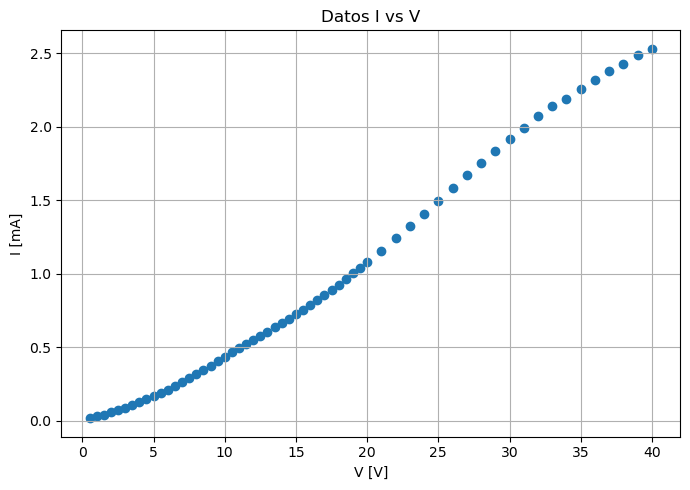

In [33]:
# ============================================================
# 4. Gráfica de datos crudos: I vs V
# ============================================================


plt.figure(figsize=(7, 5))

if "hoja" in df.columns:
    for nombre, grupo in df.groupby("hoja"):
        plt.scatter(grupo["V_V"], grupo["I_A"], label=nombre)
    plt.legend()
else:
    plt.scatter(df["V_V"], df["I_A"]*10**3)

plt.xlabel("V [V]")
plt.ylabel("I [mA]")
plt.title("Datos I vs V")
plt.grid(True)
plt.tight_layout()
plt.show()

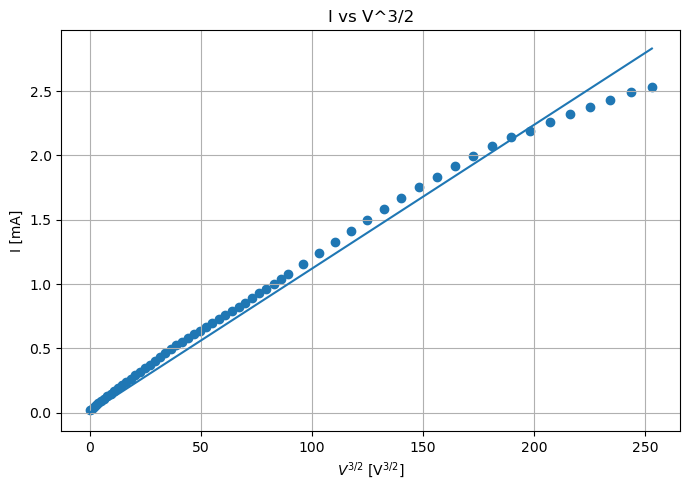

In [47]:
# ============================================================
# 5. Gráfica linealizada: I vs V^(3/2)
# ============================================================

x_line = np.linspace(0, x.max(), 300)
y_line = 1e3*m_fit * x_line

plt.figure(figsize=(7, 5))

if "hoja" in df.columns:
    for nombre, grupo in df.groupby("hoja"):
        xg = grupo["V_V"].to_numpy()**(3/2)
        yg = 1e3*grupo["I_A"].to_numpy()
        plt.scatter(xg, yg, label=nombre)
    plt.legend()
else:
    plt.scatter(x, 1e3*y)

plt.plot(
    x_line,
    y_line,
    label=fr"Ajuste: $I=mV^{{3/2}}$, $m={1e3*m_fit:.3e}$"
)

plt.xlabel(r"$V^{3/2}$ [$\mathrm{V}^{3/2}$]")
plt.ylabel("I [mA]")
plt.title("I vs V^3/2")
plt.grid(True)
plt.tight_layout()
plt.show()

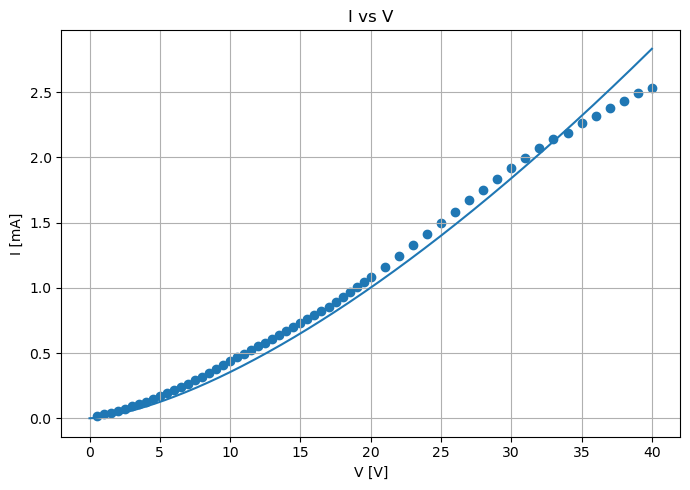

In [48]:
# ============================================================
# 6. Curva ajustada sobre los datos crudos: I vs V
# ============================================================

V_line = np.linspace(0, V.max(), 300)
I_line = 1e3*m_fit * V_line**(3/2)

plt.figure(figsize=(7, 5))

if "hoja" in df.columns:
    for nombre, grupo in df.groupby("hoja"):
        plt.scatter(grupo["V_V"], 1e3*grupo["I_A"], label=nombre)
    plt.legend()
else:
    plt.scatter(V, 1e3*I)

plt.plot(
    V_line,
    I_line,
    label=fr"Ajuste: $I={1e3*m_fit:.3e}V^{{3/2}}$"
)

plt.xlabel("V [V]")
plt.ylabel("I [mA]")
plt.title("I vs V")
plt.grid(True)
plt.tight_layout()
plt.show()

In [56]:

# ============================================================
# 2. Linealización: ln(I) = p ln(V) + ln(m)
# ============================================================

x = np.log(V)
y = np.log(I)

# Ajuste lineal con intercepto: y = p x + b
# donde b = ln(m)
coef, cov = np.polyfit(x, y, deg=1, cov=True)

p_fit = coef[0]
ln_m_fit = coef[1]

sigma_p = np.sqrt(cov[0, 0])
sigma_ln_m = np.sqrt(cov[1, 1])

m_fit = np.exp(ln_m_fit)
sigma_m = m_fit * sigma_ln_m

# Predicción del ajuste en escala logarítmica
y_fit = p_fit * x + ln_m_fit

# ============================================================
# 3. R^2 del ajuste linealizado
# ============================================================

SSE = np.sum((y - y_fit)**2)
SST = np.sum((y - np.mean(y))**2)

R2 = 1 - SSE/SST

# ============================================================
# 4. Resultados
# ============================================================

print("Ajuste linealizado:")
print(f"ln(I) = p ln(V) + ln(m)")
print()
print(f"p = {p_fit:.6f} ± {sigma_p:.6f}")
print(f"ln(m) = {ln_m_fit:.6f} ± {sigma_ln_m:.6f}")
print(f"m = ({m_fit:.6e} ± {sigma_m:.6e}) A / V^p")
print(f"R^2 = {R2:.6f}")

error = (p_fit-1.5)/1.5

print()
print(f"p esperado = 1.5")
print(f"diferencia = {100*error}%")

Ajuste linealizado:
ln(I) = p ln(V) + ln(m)

p = 1.243086 ± 0.013270
ln(m) = -10.568168 ± 0.035615
m = (2.572190e-05 ± 9.160735e-07) A / V^p
R^2 = 0.993433

p esperado = 1.5
diferencia = -17.1275702978792%


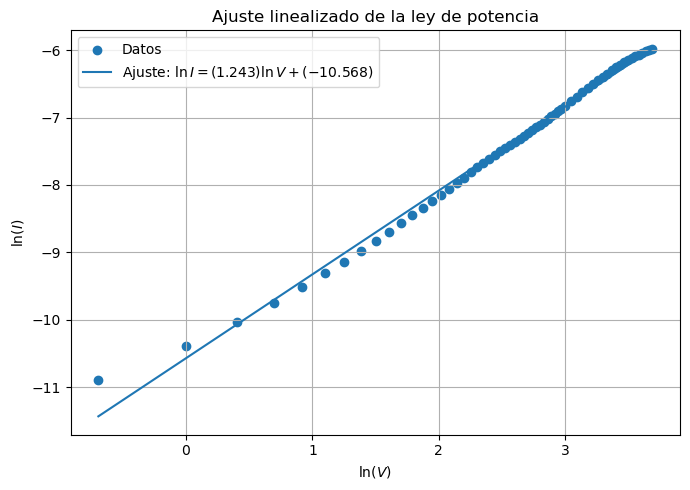

In [51]:
# ============================================================
# 5. Gráfica linealizada: ln(I) vs ln(V)
# ============================================================

x_line = np.linspace(x.min(), x.max(), 300)
y_line = p_fit * x_line + ln_m_fit

plt.figure(figsize=(7, 5))

plt.scatter(x, y, label="Datos")
plt.plot(
    x_line,
    y_line,
    label=fr"Ajuste: $\ln I = ({p_fit:.3f})\ln V + ({ln_m_fit:.3f})$"
)

plt.xlabel(r"$\ln(V)$")
plt.ylabel(r"$\ln(I)$")
plt.title("Ajuste linealizado de la ley de potencia")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()